In [1]:
import random
import pylab as plt
import torch

from torch.utils.data import DataLoader, RandomSampler

from sklearn import datasets

import sys
sys.path.append('../../')
from notebook_utils import plot_dset, plot_contour

import lightning as L
from dal_toolbox.datasets.ssl_wrapper import PiModelWrapper
from dal_toolbox.models.deterministic.base_semi import DeterministicPiModel
from dal_toolbox.models.deterministic.simplenet import SimpleNet as Net
from dal_toolbox.models.utils.callbacks import MetricHistory

In [2]:
X, y = datasets.make_moons(250, noise=.05, random_state=42)
X = (X - X.mean(0)) / X.std(0)
X = torch.from_numpy(X).float()
y = torch.from_numpy(y).long()

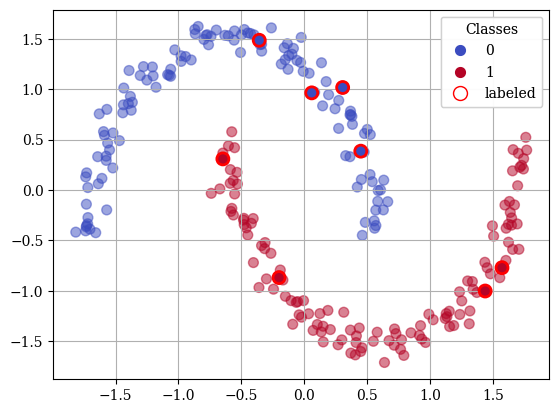

In [3]:
random.seed(1)
indices_class0 = [i for i in range(len(y)) if y[i] == 0]
indices_class1 = [i for i in range(len(y)) if y[i] == 1]
labeled_indices = random.sample(indices_class0, k=4) + random.sample(indices_class1, k=4)
unlabeled_indices = [i for i in range(X.shape[0]) if i not in labeled_indices]

X_labeled, y_labeled = X[labeled_indices], y[labeled_indices]
X_unlabeled, y_unlabeled = X[unlabeled_indices], y[unlabeled_indices]

labeled_ds = torch.utils.data.TensorDataset(X_labeled, y_labeled)
unlabeled_ds = torch.utils.data.TensorDataset(X_unlabeled, y_unlabeled)

plot_dset(X_l=X_labeled, y_l=y_labeled, X_u=X_unlabeled, y_u=y_unlabeled)

## Pi-Model

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type             | Params
---------------------------------------------------
0 | model         | SimpleNet        | 17.2 K
1 | loss_fn       | CrossEntropyLoss | 0     
2 | train_metrics | ModuleDict       | 0     
3 | val_metrics   | ModuleDict       | 0     
---------------------------------------------------
17.2 K    Trainable params
0         Non-trainable params
17.2 K    Total params
0.069     Total estimated model params size (MB)


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=10000` reached.


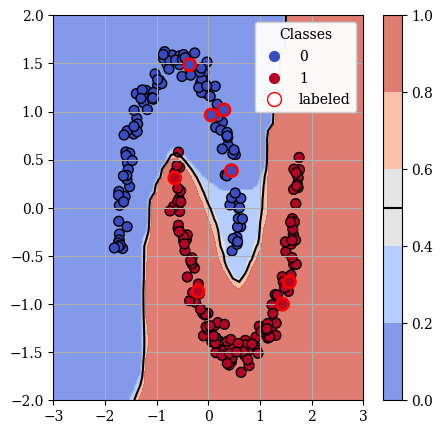

In [4]:
torch.manual_seed(0)

num_epochs = 100 # number of epochs for training
num_iter = 10000 # number of total batches over the whole training
batch_size = 32 # batch_size of labeled samples per iteration
u_ratio = 1 # Ratio of unlabeled samples to labeled samples per batch
lambda_u = 10 # Ratio of unsupervised loss partition to supervised loss of total loss
unsup_warmup = 0.4 # Warm Up Factor for unsupervised loss during training
opt_kwargs = dict(lr=0.1, weight_decay=0.0000, momentum=.9,)

num_iter_per_epoch = num_iter // num_epochs
labeled_sampler = RandomSampler(labeled_ds, num_samples=num_iter_per_epoch*batch_size)
supervised_loader = DataLoader(labeled_ds, batch_size=batch_size, sampler=labeled_sampler)
unlabeled_ds_weak = PiModelWrapper(unlabeled_ds, '/tmp', transforms_weak=lambda x: x + torch.randn_like(x)*.2)
unlabeled_sampler = RandomSampler(unlabeled_ds_weak, num_samples=u_ratio*num_iter_per_epoch*batch_size)
unsupervised_loader = DataLoader(unlabeled_ds_weak, batch_size=batch_size*u_ratio, sampler=unlabeled_sampler)

model = Net(dropout_rate=0, num_classes=2)
optimizer = torch.optim.SGD(model.parameters(), **opt_kwargs)
model = DeterministicPiModel(
    model, 
    num_classes=2, 
    unsup_warmup=unsup_warmup,
    unsup_weight=lambda_u, 
    optimizer=optimizer
)

history = MetricHistory()
trainer = L.Trainer(enable_checkpointing=False, max_steps=num_iter, callbacks=[history])
trainer.fit(model, train_dataloaders={'labeled': supervised_loader, 'unlabeled': unsupervised_loader})

model.eval()
plt.figure(figsize=(5, 5))
plot_contour(model, X_labeled, y_labeled, X_unlabeled, y_unlabeled, x_domain=(-3, 3), y_domain=(-2, 2))
plt.show()